# Exploratory Data Analysis on Retail Sales Data

## Oasis Infobyte Data Analytics Internship

**Intern:** Deborah Titilope Ajisafe

### Project Objective

This project explores a retail sales dataset to uncover customer purchasing behaviour, sales trends, product performance, and actionable business insights using Python for Exploratory Data Analysis (EDA).

**Tools Used**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [2]:
# Import Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside notebook
%matplotlib inline

# Improve plot appearance
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [4]:
df = pd.read_csv("C:/Users/USER/Documents/OIBSIP/DataAnalytics-L1-EDARetailSales/retail_sales.csv.csv")
# Display first five rows
df.head()
# Shape of dataset
df.shape
# Dataset information
df.info()
# Check missing values
df.isnull().sum()
# Check duplicate rows
df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


0

### Observation

- The dataset contains 1000 rows and 9 columns.
- There are no missing values.
- The data types appear appropriate for analysis, although the Date column may need conversion to datetime format.
- No duplicate records were found.

In [11]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"])
# Confirm the conversion
df.info()
# Create Year, Month and Quarter columns
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month_name()
df["Quarter"] = df["Date"].dt.quarter

# Display first five rows
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Year,Month,Quarter
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,2023,November,4
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2023,February,1
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,2023,January,1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,2023,May,2
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,2023,May,2


## Data Preparation
The `Date` column was successfully converted to the datetime format to enable time-based analysis.
Additional columns (`Year`, `Month`, and `Quarter`) were created to support monthly and quarterly sales trend analysis.

In [22]:
# Select numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).drop(columns=['Transaction ID'])

# Create a descriptive statistics summary
summary_stats = pd.DataFrame({
    "Mean": numerical_columns.mean(),
    "Median": numerical_columns.median(),
    "Mode": numerical_columns.mode().iloc[0],
    "Standard Deviation": numerical_columns.std()
}).round(2)

summary_stats

,Mean,Median,Mode,Standard Deviation
Age,41.39,42.0,43.0,13.68
Quantity,2.51,3.0,4.0,1.13
Price per Unit,179.89,50.0,50.0,189.68
Total Amount,456.00,135.0,50.0,560.00


## Descriptive Statistics – Observations

The descriptive statistics provide an overview of the numerical variables in the retail sales dataset and help us understand customer purchasing patterns.

### Key Findings
- The **average customer age is approximately 41 years**, while the median age is **42 years**, indicating that customers are fairly evenly distributed across adult age groups.
- Customers purchase an average of **2.5 items per transaction**, with the most common purchase quantity (**mode**) being **4 items**.
- The **average price per unit is 179.89**, whereas the median price is **50**. This large difference suggests that while many products are relatively inexpensive, a smaller number of high-priced products increase the average price.
- The **average transaction value is 456**, but the median transaction value is only **135**. This indicates that most transactions are of relatively low value, with a few high-value purchases significantly increasing the average.
- The **standard deviation of the Total Amount (560)** is relatively high, indicating considerable variation in customer spending habits.

In [25]:
#Time Series Analysis
# Monthly Sales Trend
# Arrange months in chronological order
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]
monthly_sales = (
    df.groupby("Month")["Total Amount"]
      .sum()
      .reindex(month_order)
)

monthly_sales

Month
January      36980
February     44060
March        28990
April        33870
May          53150
June         36715
July         35465
August       36960
September    23620
October      46580
November     34920
December     44690
Name: Total Amount, dtype: int64

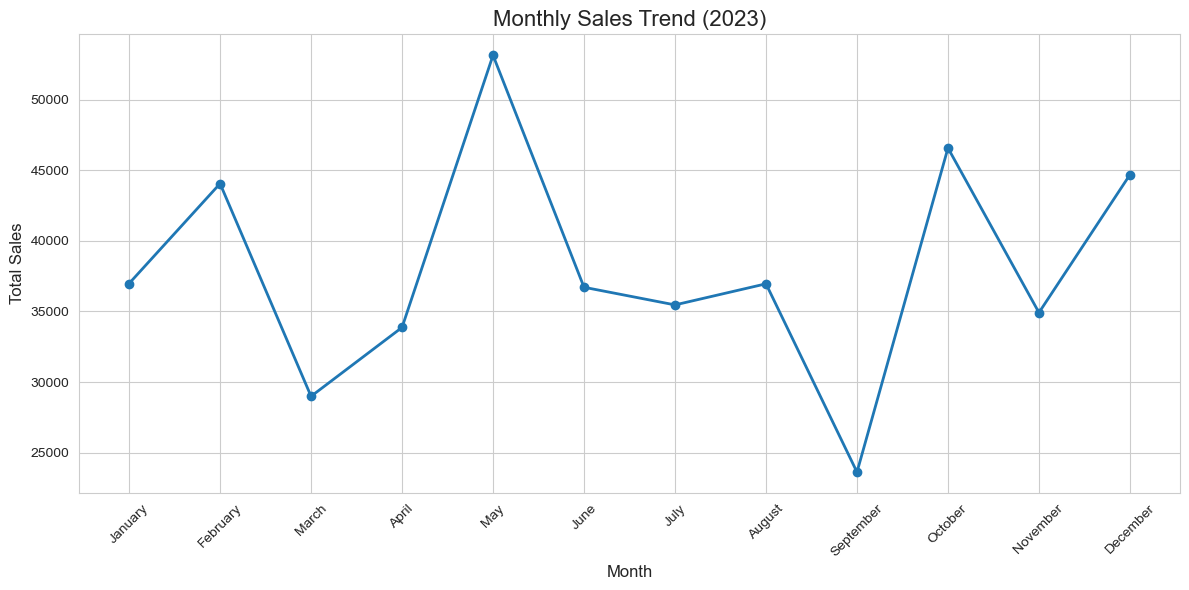

In [29]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    linewidth=2
)

plt.title("Monthly Sales Trend (2023)", fontsize=16)
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.show()

### Observation

- Monthly sales varied throughout the year, indicating fluctuations in customer purchasing behaviour.
- **May recorded the highest total sales (53,150)**, suggesting a peak period in customer demand.
- **September had the lowest total sales (23,620)**, representing the weakest sales performance during the year.
- Sales recovered after September, with **October (46,580)** and **December (44,690)** showing strong performance.
- These patterns can help businesses identify peak and low-demand periods for inventory planning, staffing, and promotional campaigns.

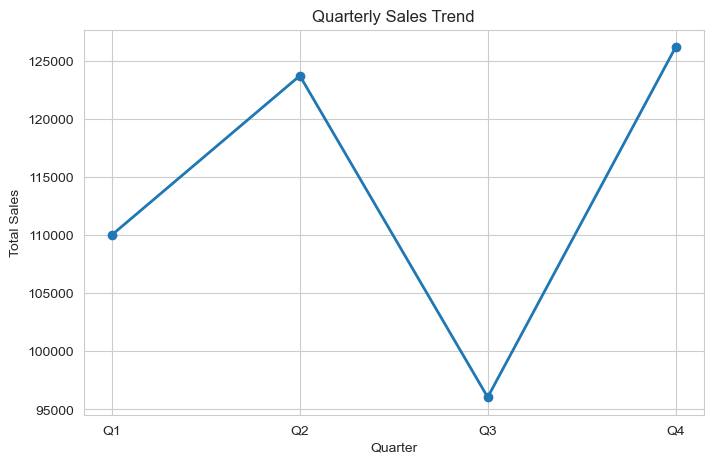

In [34]:
# Quarterly Sales Trend
quarterly_sales = (
    df.groupby("Quarter")["Total Amount"]
      .sum()
)

quarterly_sales
plt.figure(figsize=(8,5))

plt.plot(
    quarterly_sales.index,
    quarterly_sales.values,
    marker='o',
    linewidth=2
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")

plt.xticks([1,2,3,4], ["Q1","Q2","Q3","Q4"])

plt.grid(True)

plt.show()

### Observation

- Quarterly sales analysis shows that **Q4 generated the highest total revenue (126,190)**, making it the strongest-performing quarter of the year.
- **Q3 recorded the lowest sales (96,045)**, indicating a decline in customer spending during this period.
- Sales recovered significantly in Q4 after the dip in Q3, suggesting increased customer demand toward the end of the year.
- Understanding quarterly performance helps businesses allocate marketing budgets, manage inventory, and prepare for seasonal demand more effectively.

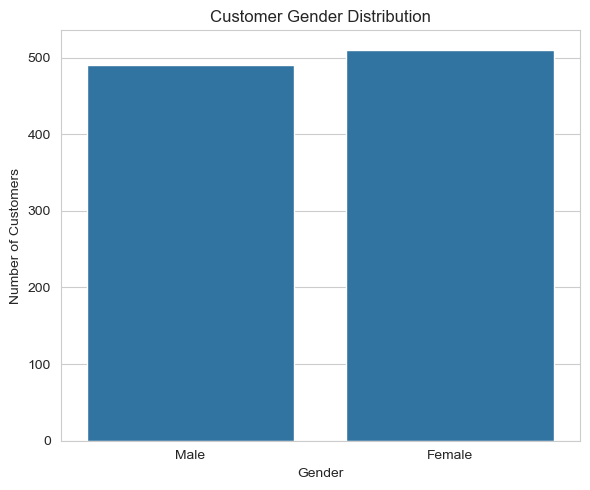

In [43]:
# Customer Demographics Analysis
gender_counts = df["Gender"].value_counts()

gender_counts
plt.figure(figsize=(6,5))

sns.countplot(data=df, x="Gender")

plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

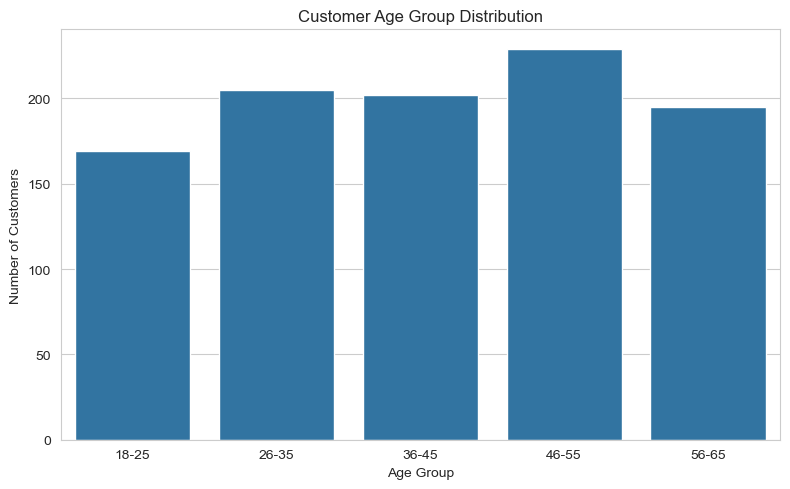

In [55]:
# Count customers by age group
age_group_counts = (
    df["Age Group"]
      .value_counts()
      .sort_index()
)

age_group_counts
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Age Group",
    order=["18-25","26-35","36-45","46-55","56-65"]
)

plt.title("Customer Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

## Customer Demographics Analysis 

The customer demographics analysis provides insights into the composition of the customer base by gender and age group.

### Key Findings

- The customer base is almost evenly distributed between genders, with **510 female customers (51%)** and **490 male customers (49%)**. This indicates that the business appeals equally to both male and female customers.
- The **46–55 age group** represents the largest customer segment with **229 customers**, while the **18–25 age group** has the fewest customers (**169**).
- Customer distribution across age groups is relatively balanced, with most customers falling between **26 and 55 years**, suggesting that middle-aged adults form a significant portion of the customer base.
- The balanced gender distribution and broad age representation indicate that the business serves a diverse customer population. This provides opportunities for targeted marketing campaigns and product offerings tailored to different age segments while maintaining strategies that appeal to both genders.

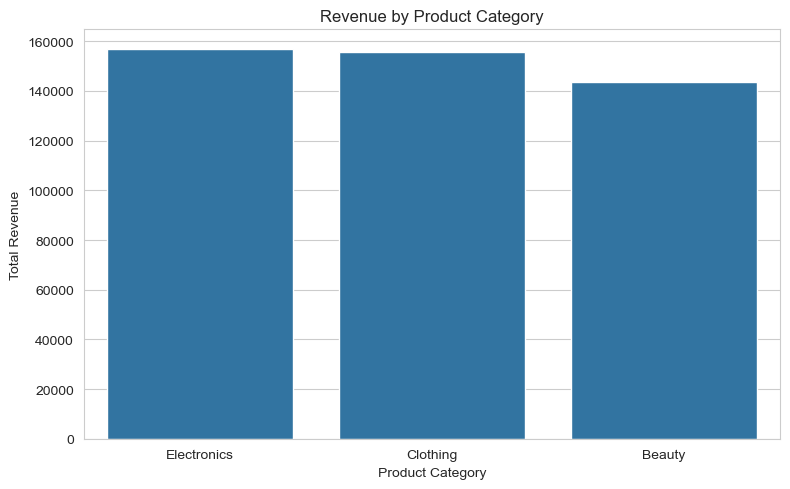

In [62]:
# Revenue by Product Category

category_revenue = (
    df.groupby("Product Category")["Total Amount"]
      .sum()
      .sort_values(ascending=False)
)

category_revenue
plt.figure(figsize=(8,5))

sns.barplot(
    data=category_revenue.reset_index(),
    x="Product Category",
    y="Total Amount"
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

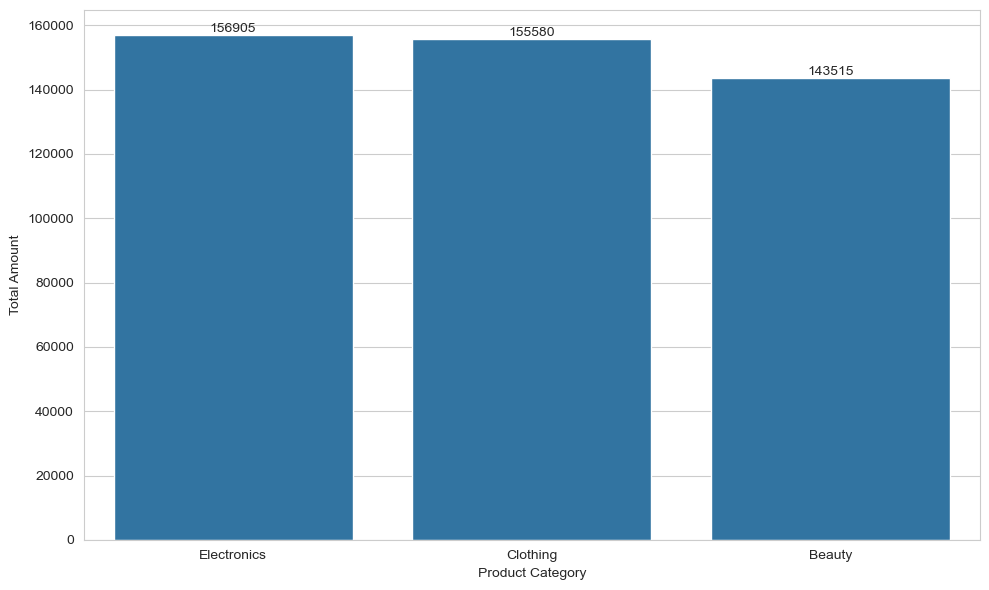

In [66]:
# Quantity Sold by Category
category_quantity = (
    df.groupby("Product Category")["Quantity"]
      .sum()
      .sort_values(ascending=False)
)

category_quantity
ax = sns.barplot(
    data=category_revenue.reset_index(),
    x="Product Category",
    y="Total Amount"
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.tight_layout()
plt.show()

## Product Analysis

### Key Findings

The product analysis examined both total revenue and sales volume across the available product categories.

- **Electronics** generated the highest total revenue (**156,905**), followed closely by **Clothing** (**155,580**), while **Beauty** generated the lowest revenue (**143,515**).
- **Clothing** recorded the highest sales volume with **894 units sold**, making it the most frequently purchased product category.
- Although **Electronics** sold fewer units (**849**) than Clothing, it generated the highest revenue. This suggests that electronics products have a higher average selling price than products in the other categories.
- **Beauty** had both the lowest revenue and the fewest units sold, indicating relatively lower customer demand compared to the other product categories.

### Business Implications

- The business should continue investing in the Electronics category due to its strong revenue-generating potential.
- Since Clothing has the highest purchase volume, promotional strategies such as bundle offers or customer loyalty programs could further increase revenue.
- The Beauty category may require targeted marketing campaigns or product diversification to improve customer demand and sales performance.

In [69]:
# Correlation Analysis
# Select numerical columns excluding Transaction ID

correlation_data = df.drop(columns=["Transaction ID"]).select_dtypes(include=["int64", "float64"])

# Compute the correlation matrix
correlation_matrix = correlation_data.corr()

correlation_matrix

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


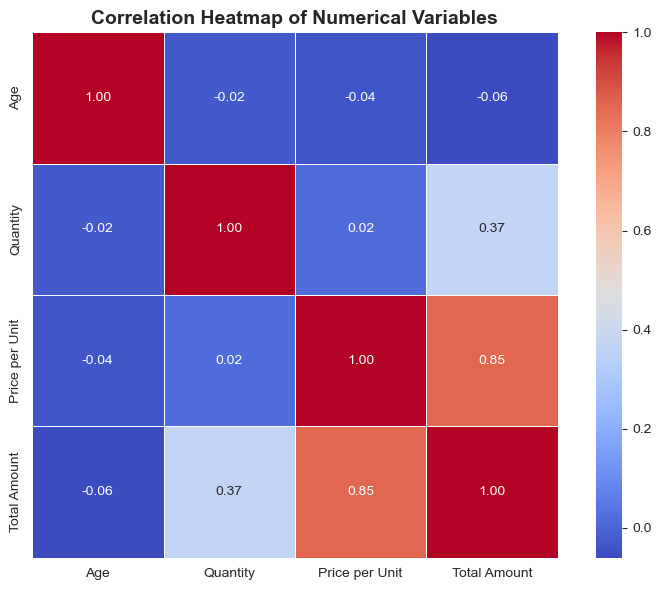

In [73]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    square=True
)

plt.title("Correlation Heatmap of Numerical Variables",
          fontsize=14,
          fontweight="bold")

plt.tight_layout()

plt.show()

## Correlation Analysis

### Key Findings

The correlation heatmap illustrates the relationships among the numerical variables in the retail sales dataset.

- **Price per Unit** and **Total Amount** exhibit a **strong positive correlation (r = 0.85)**, indicating that higher-priced products generally contribute to larger transaction values.
- **Quantity** and **Total Amount** show a **moderate positive correlation (r = 0.37)**, suggesting that purchasing more items tends to increase the total amount spent.
- **Age** has very weak negative correlations with **Quantity (-0.02)**, **Price per Unit (-0.04)**, and **Total Amount (-0.06)**. This indicates that customer age has little influence on purchasing behaviour in this dataset.
- Overall, the analysis suggests that **product pricing and purchase quantity are stronger drivers of sales revenue than customer age**.

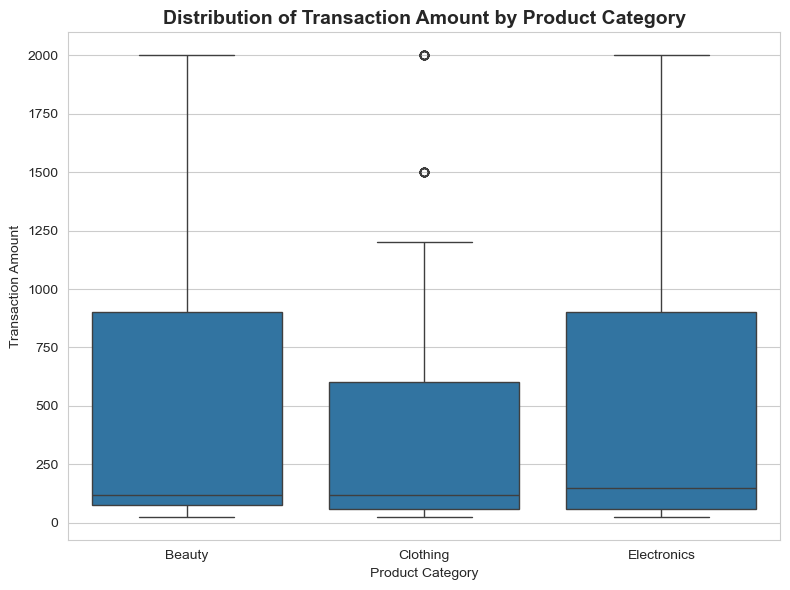

In [76]:
# Transaction Amount Distribution by Product Category
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x="Product Category",
    y="Total Amount"
)

plt.title("Distribution of Transaction Amount by Product Category",
          fontsize=14,
          fontweight="bold")

plt.xlabel("Product Category")
plt.ylabel("Transaction Amount")

plt.tight_layout()

plt.show()

## Additional Visualization

### Key Findings

The box plot provides a deeper understanding of transaction amount distributions across product categories.

- The median transaction amount is relatively similar across all product categories, indicating that a typical customer spends a comparable amount regardless of the product category.
- Transaction amounts exhibit considerable variability, particularly in the Electronics and Beauty categories, suggesting a wider range of customer spending.
- The Clothing category contains a few high-value outlier transactions, indicating occasional purchases that are substantially larger than the majority of clothing transactions.
- Overall, the distribution of transaction amounts is positively skewed, with many low-value purchases and relatively few high-value transactions. This pattern is common in retail sales and suggests that while most customers make modest purchases, a small number contribute significantly to total revenue.

# Business Recommendations

Based on the exploratory data analysis conducted on the retail sales dataset, the following recommendations are proposed to improve business performance and support data-driven decision-making.

### 1. Increase Investment in High-Revenue Product Categories
Electronics generated the highest total revenue despite selling fewer units than Clothing. The business should continue investing in high-value electronics products, ensuring adequate inventory levels and effective marketing campaigns to maximize revenue.

### 2. Leverage the Popularity of Clothing Products
Clothing recorded the highest sales volume, indicating strong customer demand. Introducing bundle offers, loyalty programs, or cross-selling opportunities could further increase revenue from this category.

### 3. Improve the Performance of the Beauty Category
Beauty products generated the lowest revenue and sold the fewest units. The business should investigate customer preferences and consider promotional discounts, product diversification, or targeted marketing campaigns to increase sales.

### 4. Prepare for Seasonal Sales Fluctuations
Monthly and quarterly sales analysis revealed noticeable fluctuations throughout the year, with Q4 recording the highest sales and September the lowest. The business should plan inventory, staffing, and promotional activities around these seasonal trends to optimize operations.

### 5. Focus Marketing Strategies Beyond Customer Age
The correlation analysis showed that customer age has little influence on purchasing behaviour, while product pricing and purchase quantity have a much stronger relationship with transaction value. Marketing efforts should therefore prioritize customer purchasing behaviour and product preferences rather than age alone.

# Conclusion

This exploratory data analysis examined customer demographics, sales trends, product performance, and the relationships among key numerical variables within the retail sales dataset.

The analysis revealed that Electronics generated the highest revenue, while Clothing achieved the highest sales volume. Customer demographics showed a balanced distribution across gender and age groups, indicating a diverse customer base. Time series analysis identified seasonal fluctuations in sales, with Q4 recording the strongest performance. Correlation analysis further demonstrated that transaction value is more strongly influenced by product price and purchase quantity than by customer age.

Overall, the findings provide valuable insights that can support inventory planning, marketing strategies, pricing decisions, and overall business growth. By leveraging these insights, organizations can make more informed decisions and improve operational performance through data-driven strategies.